In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. DATA LOADING
Primero vamos a importar la base de datos con la que vamos a trabajar

## 🔴 CORRECCIONES REALIZADAS (BUSCAR ESTAS MARCAS)

**Celda 1 - CORRECCIÓN 1**: Análisis de Outliers (IQR) - Detecta outliers en columnas numéricas  
**Celda 1 - CORRECCIÓN 2**: Tratamiento de Zipcode con One-Hot Encoding (83 -> 82 columnas dummy)  
**Celda - CORRECCIÓN 3**: Evaluación en TEST SET de Red Neuronal (usando test_dataloader)  
**Celda - CORRECCIÓN 4**: Comparación Final RF vs Red Neuronal (gráficas y métricas)  
**Celda - CAMBIO**: StandardScaler → RobustScaler (por los outliers detectados)

---

In [ ]:
import kagglehub
from pathlib import Path
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")
csv_path = Path(path) / "kc_house_data.csv"
print("Dataset downloaded to:", csv_path)

d:\Documentos_TheReal\IA\PIA\Apuntes\Segunda Evaluación\ia25-master-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\TheRealSerginho\.cache\kagglehub\datasets\harlfoxem\housesalesprediction\versions\1\kc_house_data.csv


In [ ]:
print(csv_path) #Mediante esta línea obtenemos la ruta donde se ha guardado el dataset
import shutil
destino = "D:\\Documentos_TheReal\\IA\\PIA\\Apuntes\\Segunda Evaluación\\ia25-master-main\\sergio_ejercicios\\king_county_Sergio\\data" #Guardamos el dataset en la ruta que deseamos para poder trabajar con el
shutil.copytree(path, destino, dirs_exist_ok=True)

C:\Users\TheRealSerginho\.cache\kagglehub\datasets\harlfoxem\housesalesprediction\versions\1\kc_house_data.csv


'D:\\Documentos_TheReal\\IA\\PIA\\Apuntes\\Segunda Evaluación\\ia25-master-main\\sergio_ejercicios\\king_county_Sergio\\data'

In [ ]:
df = pd.read_csv("data/kc_house_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

Hasta ahora tengo la base de datos, ya comprobé las 5 primeras filas y todos los tipos de datos de las columnas. Me sorprende la columna "data" que es la única que es un objecto, voy a empezar por tratar esta, ya me fije que por ejemplo este valor "20141013T000000" se corresponde con la 10-13-2014 a las 00:00:00" por lo que el formato es YYYYMMDDTHHMMSS

In [ ]:
df['date']= pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday  # 0=Lunes, 6=Domingo
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[us]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  int64         
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  int64         
 6   sqft_lot       21613 non-null  int64         
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   21613 non-null 

In [ ]:
#Como ya dividimos la fecha en los distintos componentes podemos eliminar la columna origiinal
df.drop(columns=['date'], inplace= True)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   price          21613 non-null  float64
 2   bedrooms       21613 non-null  int64  
 3   bathrooms      21613 non-null  float64
 4   sqft_living    21613 non-null  int64  
 5   sqft_lot       21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated   21613 non-null  int64  
 15  zipcode        21613 non-null  int64  
 16  lat            21613 non-null  float64
 17  long           21613 non-null  float64
 18  sqft_living15  21

In [ ]:
df.isnull().sum()

id               0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
year             0
month            0
day              0
weekday          0
dtype: int64

In [ ]:
correlaciones = df.corr(numeric_only=True)

correlaciones["price"].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
year             0.003576
weekday         -0.001695
month           -0.010081
day             -0.014670
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64

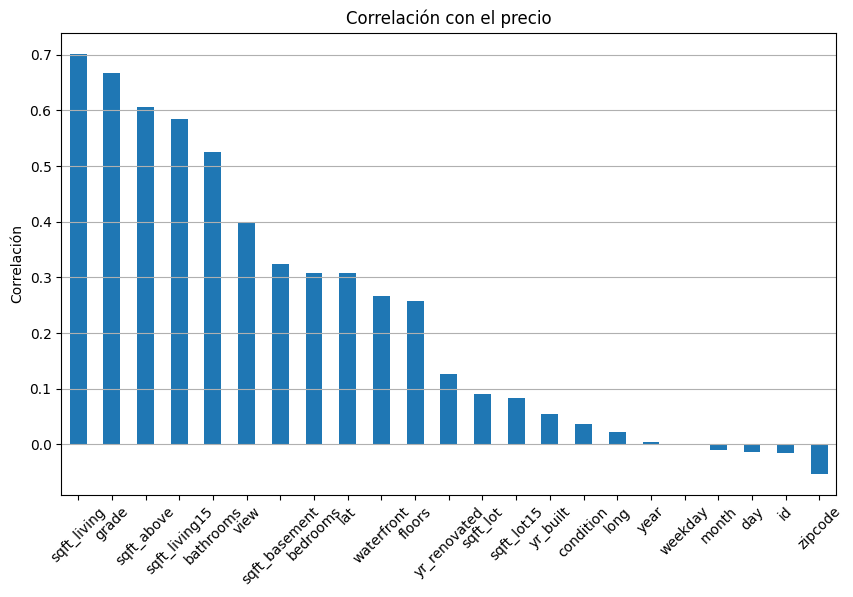

In [ ]:
import matplotlib.pyplot as plt

# Ordenamos (quitando el propio price)
corr = correlaciones["price"].drop("price").sort_values(ascending=False)

plt.figure(figsize=(10,6))
corr.plot(kind='bar')

plt.title("Correlación con el precio")
plt.ylabel("Correlación")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

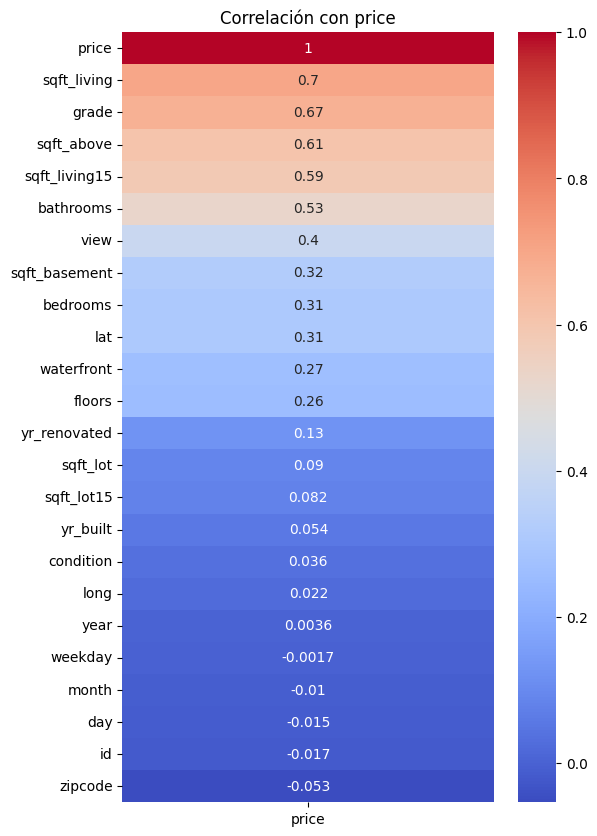

In [ ]:
plt.figure(figsize=(6,10))
sns.heatmap(correlaciones[["price"]].sort_values(by="price", ascending=False),
            annot=True,
            cmap="coolwarm")

plt.title("Correlación con price")
plt.show()

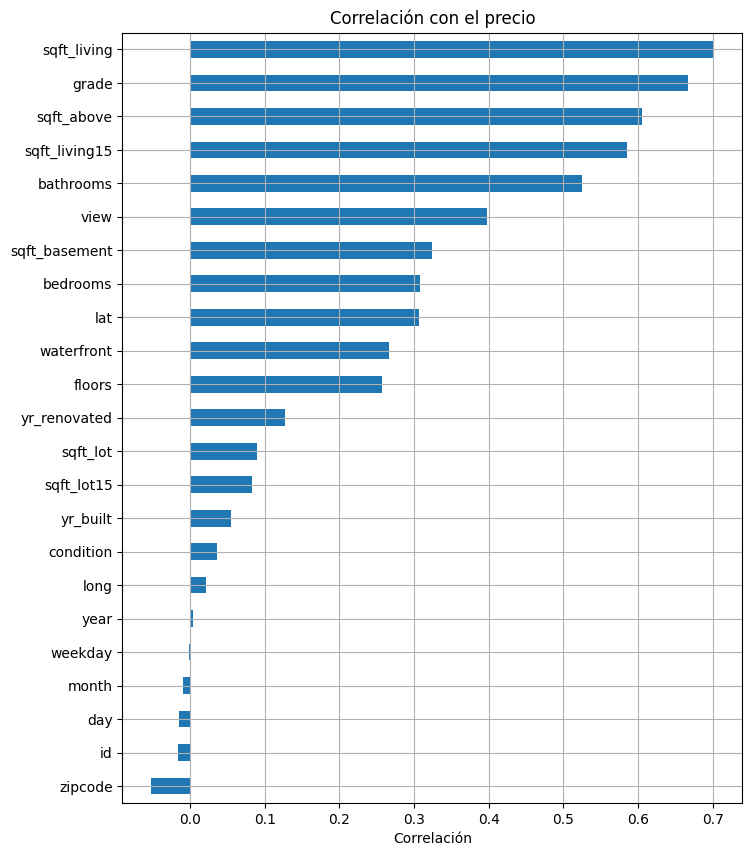

In [ ]:
corr = correlaciones["price"].drop("price").sort_values()

plt.figure(figsize=(8,10))
corr.plot(kind='barh')

plt.title("Correlación con el precio")
plt.xlabel("Correlación")
plt.grid()

plt.show()

Estos son tres ejemplos de la correlación con el precio. 
De esta manera para nuestro modelo utilizaremos las variables "sqft_living","grade","sqft_above" y "sqft_living15". Estas son las variables que guardan más relación con el precio.


In [ ]:
#Procedemos a comprobar las estadísticas
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day,weekday
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,...,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652,2014.322954,6.574423,15.688197,2.010734
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,...,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631,0.467616,3.115308,8.635063,1.460592
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,2014.000000,1.000000,1.000000,0.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,...,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000,2014.000000,4.000000,8.000000,1.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,...,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000,2014.000000,6.000000,16.000000,2.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,...,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,2015.000000,9.000000,23.000000,3.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,2015.000000,12.000000,31.000000,6.000000


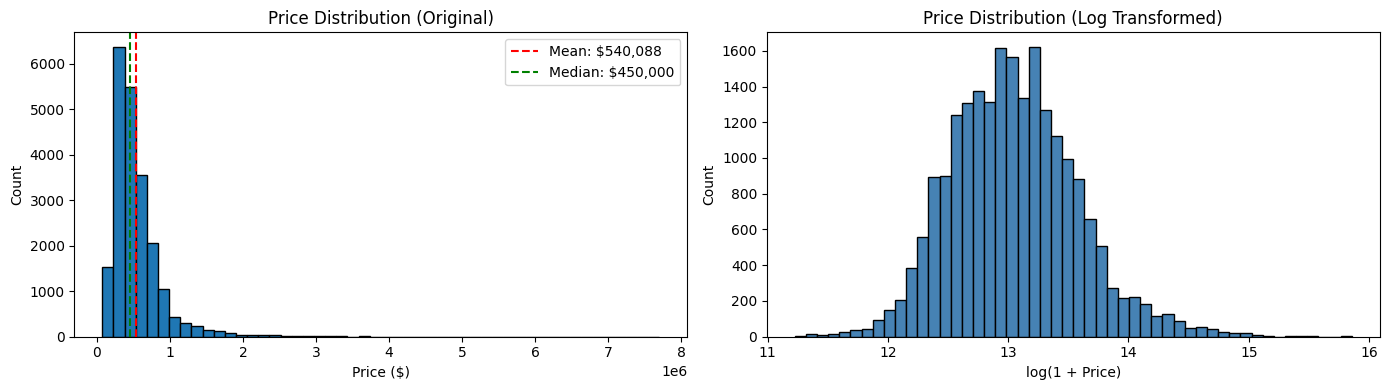

Skewness (original): 4.02
Skewness (log): 0.43


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Original distribution
axes[0].hist(df["price"], bins=50, edgecolor='black')
axes[0].axvline(df["price"].mean(), color='r', linestyle='--', label=f'Mean: ${df["price"].mean():,.0f}')
axes[0].axvline(df["price"].median(), color='g', linestyle='--', label=f'Median: ${df["price"].median():,.0f}')
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")
axes[0].set_title("Price Distribution (Original)")
axes[0].legend()

# Log-transformed
axes[1].hist(np.log1p(df["price"]), bins=50, edgecolor='black', color='steelblue')
axes[1].set_xlabel("log(1 + Price)")
axes[1].set_ylabel("Count")
axes[1].set_title("Price Distribution (Log Transformed)")

plt.tight_layout()
plt.show()

print(f"Skewness (original): {df['price'].skew():.2f}")
print(f"Skewness (log): {np.log1p(df['price']).skew():.2f}")
     

Con estos datos sacamos como conclusión que existe una asimetría, por lo que tenemos dos opciones, usar un modelo que sea robusto a datos sesgados 

4. TEMPORAL ANALYSIS

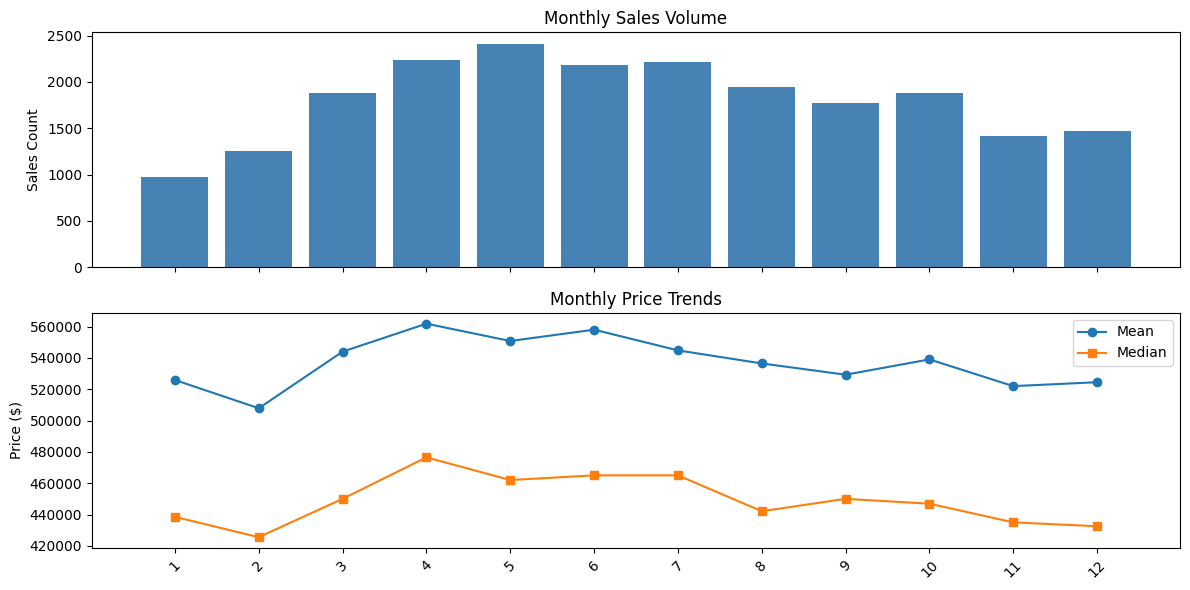

In [ ]:
# Monthly patterns
#df["year_month"] = df["date_parsed"].dt.to_period("M")
monthly = df.groupby("month").agg(
    count=("price", "count"),
    mean_price=("price", "mean"),
    median_price=("price", "median")
)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].bar(range(len(monthly)), monthly["count"], color="steelblue")
axes[0].set_ylabel("Sales Count")
axes[0].set_title("Monthly Sales Volume")

axes[1].plot(range(len(monthly)), monthly["mean_price"], marker="o", label="Mean")
axes[1].plot(range(len(monthly)), monthly["median_price"], marker="s", label="Median")
axes[1].set_ylabel("Price ($)")
axes[1].set_title("Monthly Price Trends")
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels([str(p) for p in monthly.index], rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

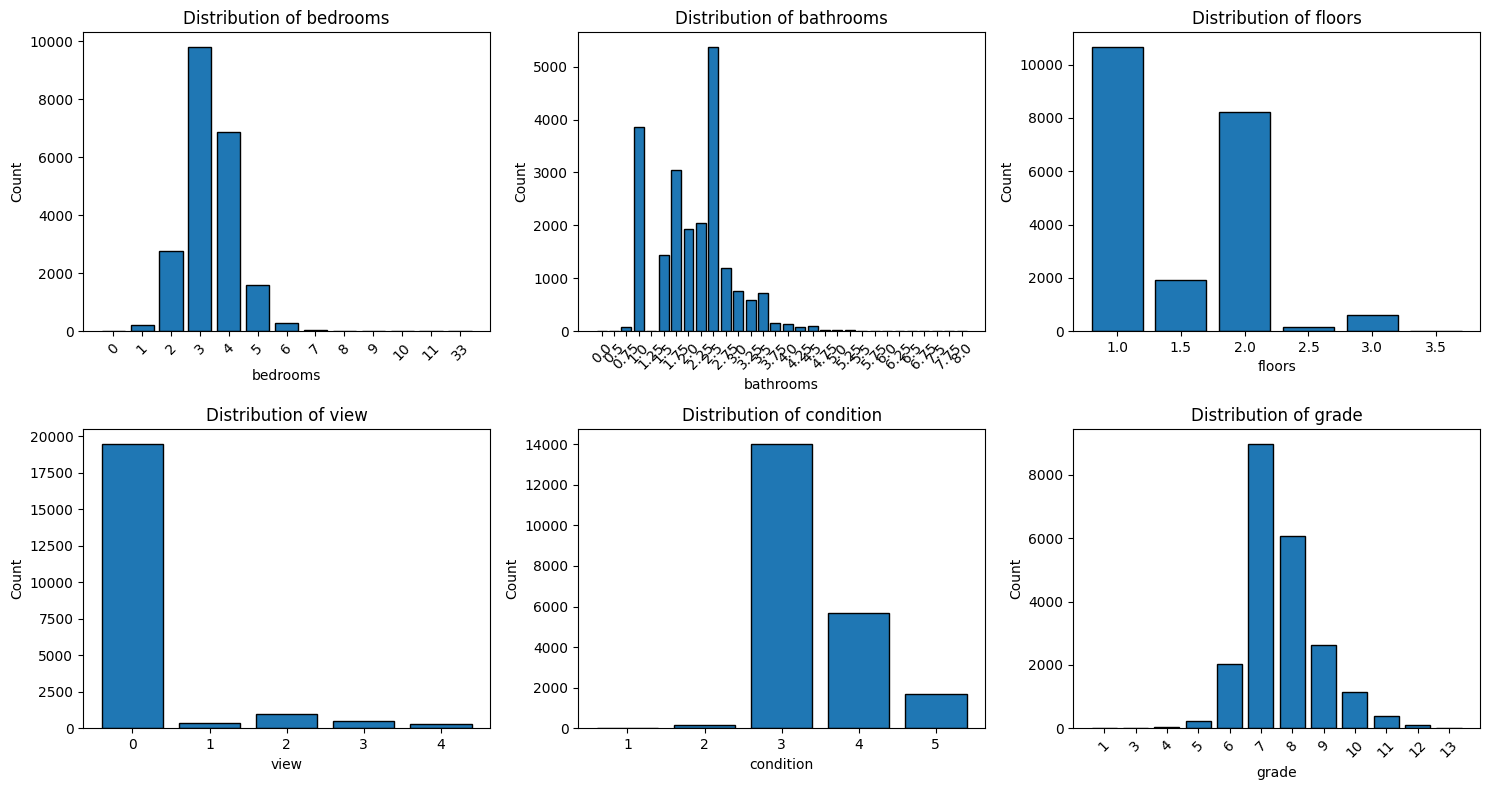

In [ ]:
discrete_features = ["bedrooms", "bathrooms", "floors", "view", "condition", "grade"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, discrete_features):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, edgecolor='black')
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {col}")
    if len(counts) > 10:
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
waterfront_counts = df["waterfront"].value_counts()
print(f"Waterfront properties: {waterfront_counts.get(1, 0):,} ({100*waterfront_counts.get(1, 0)/len(df):.2f}%)")
print(f"Non-waterfront properties: {waterfront_counts.get(0, 0):,} ({100*waterfront_counts.get(0, 0)/len(df):.2f}%)")
     

Waterfront properties: 163 (0.75%)
Non-waterfront properties: 21,450 (99.25%)


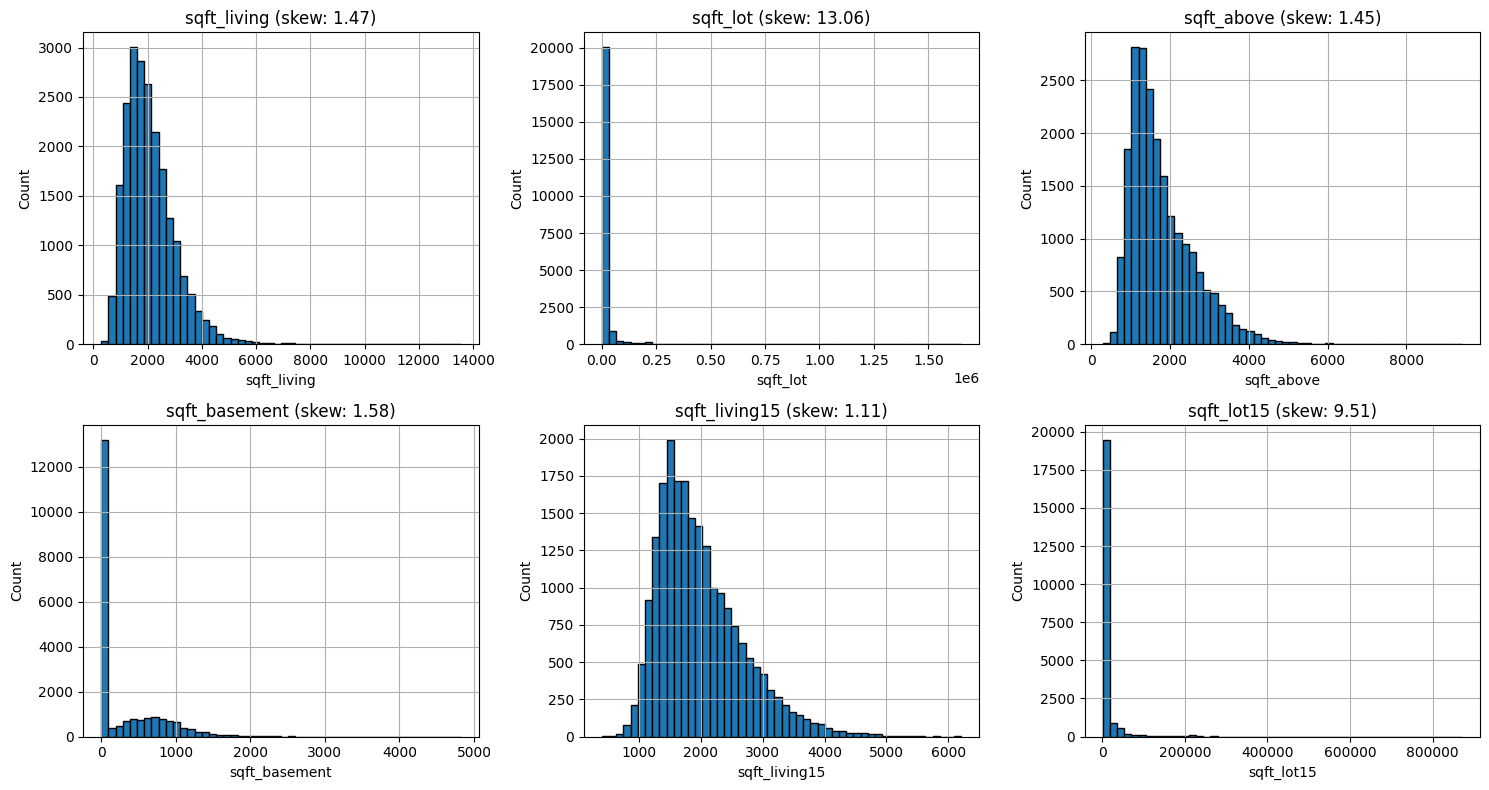

In [ ]:
sqft_features = ["sqft_living", "sqft_lot", "sqft_above", "sqft_basement", "sqft_living15", "sqft_lot15"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, sqft_features):
    df[col].hist(bins=50, ax=ax, edgecolor='black')
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    skew = df[col].skew()
    ax.set_title(f"{col} (skew: {skew:.2f})")

plt.tight_layout()
plt.show()

In [ ]:
# First, let's examine the yr_renovated column to understand its values
print("Year Renovated - Summary Statistics:")
print(df["yr_renovated"].describe())
print(f"\nUnique values count: {df['yr_renovated'].nunique()}")
print(f"\nValue distribution (showing most common):")
print(df["yr_renovated"].value_counts().head(10))

Year Renovated - Summary Statistics:
count    21613.000000
mean        84.402258
std        401.679240
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2015.000000
Name: yr_renovated, dtype: float64

Unique values count: 70

Value distribution (showing most common):
yr_renovated
0       20699
2014       91
2013       37
2003       36
2005       35
2000       35
2007       35
2004       26
1990       25
2006       24
Name: count, dtype: int64


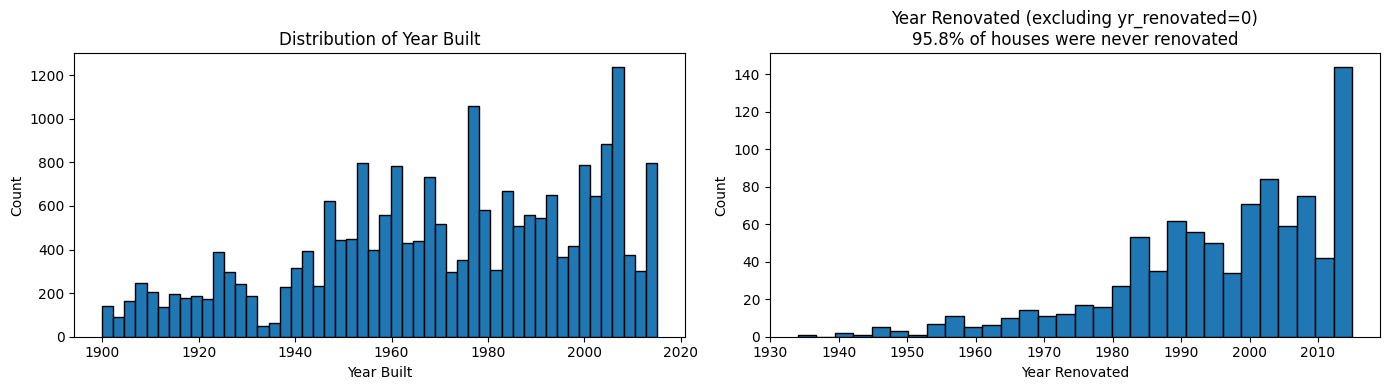

Year built range: 1900 - 2015
Houses with renovation record: 914 (4.2%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Year built distribution
axes[0].hist(df["yr_built"], bins=50, edgecolor='black')
axes[0].set_xlabel("Year Built")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Year Built")

# Year renovated - filter out zeros (non-renovated houses) to see actual renovation years
renovated = df[df["yr_renovated"] > 0]["yr_renovated"]
not_renovated_pct = 100 * (len(df) - len(renovated)) / len(df)

axes[1].hist(renovated, bins=30, edgecolor='black')
axes[1].set_xlabel("Year Renovated")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Year Renovated (excluding yr_renovated=0)\n{not_renovated_pct:.1f}% of houses were never renovated")

plt.tight_layout()
plt.show()

print(f"Year built range: {df['yr_built'].min()} - {df['yr_built'].max()}")
print(f"Houses with renovation record: {len(renovated):,} ({100*len(renovated)/len(df):.1f}%)")

Sacamos como conclusión que muchos edificios no fueron renovados, por lo que podemos crear una nueva variable que sea binaria y diga si fue renovado o no.


In [ ]:
print(f"Number of unique zipcodes: {df['zipcode'].nunique()}")
print(f"\nSales per zipcode (top 10):")
print(df["zipcode"].value_counts().head(10))
print(f"\nSales per zipcode (bottom 5):")
print(df["zipcode"].value_counts().tail(5))

Number of unique zipcodes: 70

Sales per zipcode (top 10):
zipcode
98103    602
98038    590
98115    583
98052    574
98117    553
98042    548
98034    545
98118    508
98023    499
98006    498
Name: count, dtype: int64

Sales per zipcode (bottom 5):
zipcode
98102    105
98010    100
98024     81
98148     57
98039     50
Name: count, dtype: int64


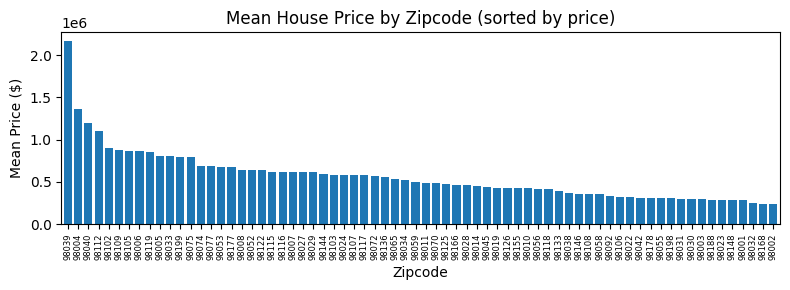


Price range across zipcodes:
  Highest avg price: 98039 ($2,160,607)
  Lowest avg price: 98002 ($234,284)


In [ ]:
# Mean price by zipcode
zipcode_price = df.groupby("zipcode")["price"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
zipcode_price.plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel("Zipcode")
ax.set_ylabel("Mean Price ($)")
ax.set_title("Mean House Price by Zipcode (sorted by price)")
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

print(f"\nPrice range across zipcodes:")
print(f"  Highest avg price: {zipcode_price.idxmax()} (${zipcode_price.max():,.0f})")
print(f"  Lowest avg price: {zipcode_price.idxmin()} (${zipcode_price.min():,.0f})")

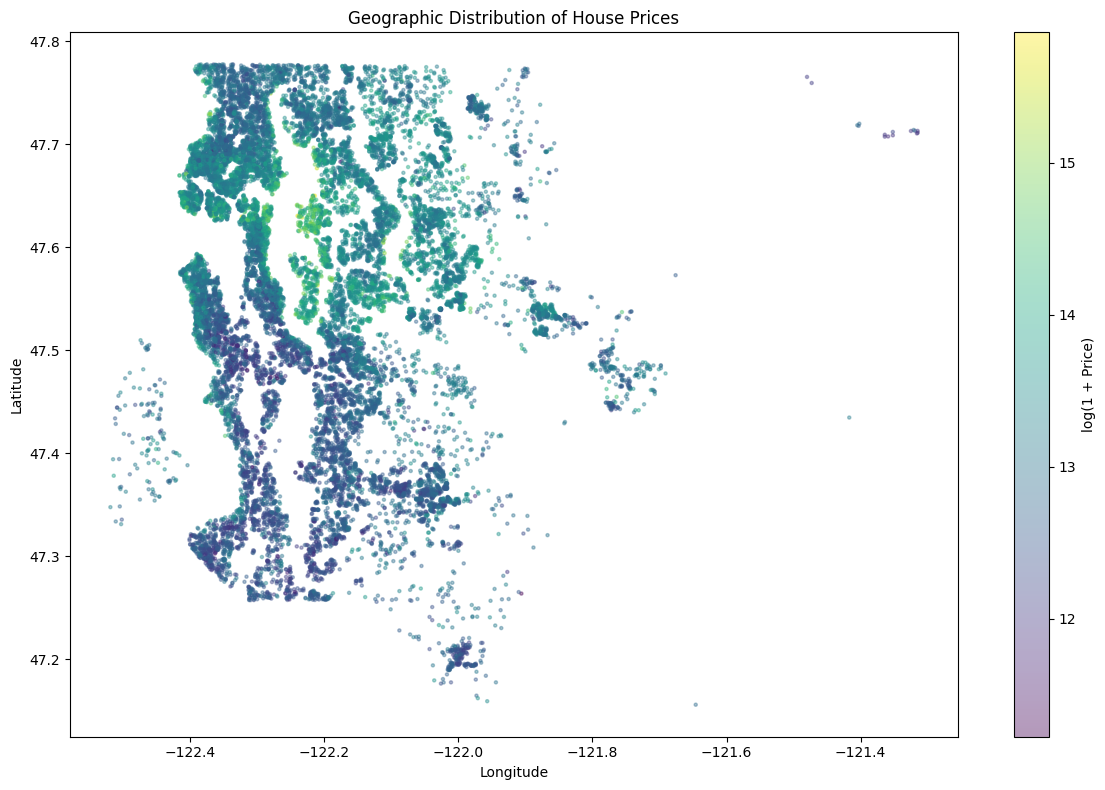

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df["long"], df["lat"],
    c=np.log1p(df["price"]),
    cmap="viridis",
    alpha=0.4,
    s=5
)
plt.colorbar(scatter, label="log(1 + Price)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of House Prices")
plt.tight_layout()
plt.show()

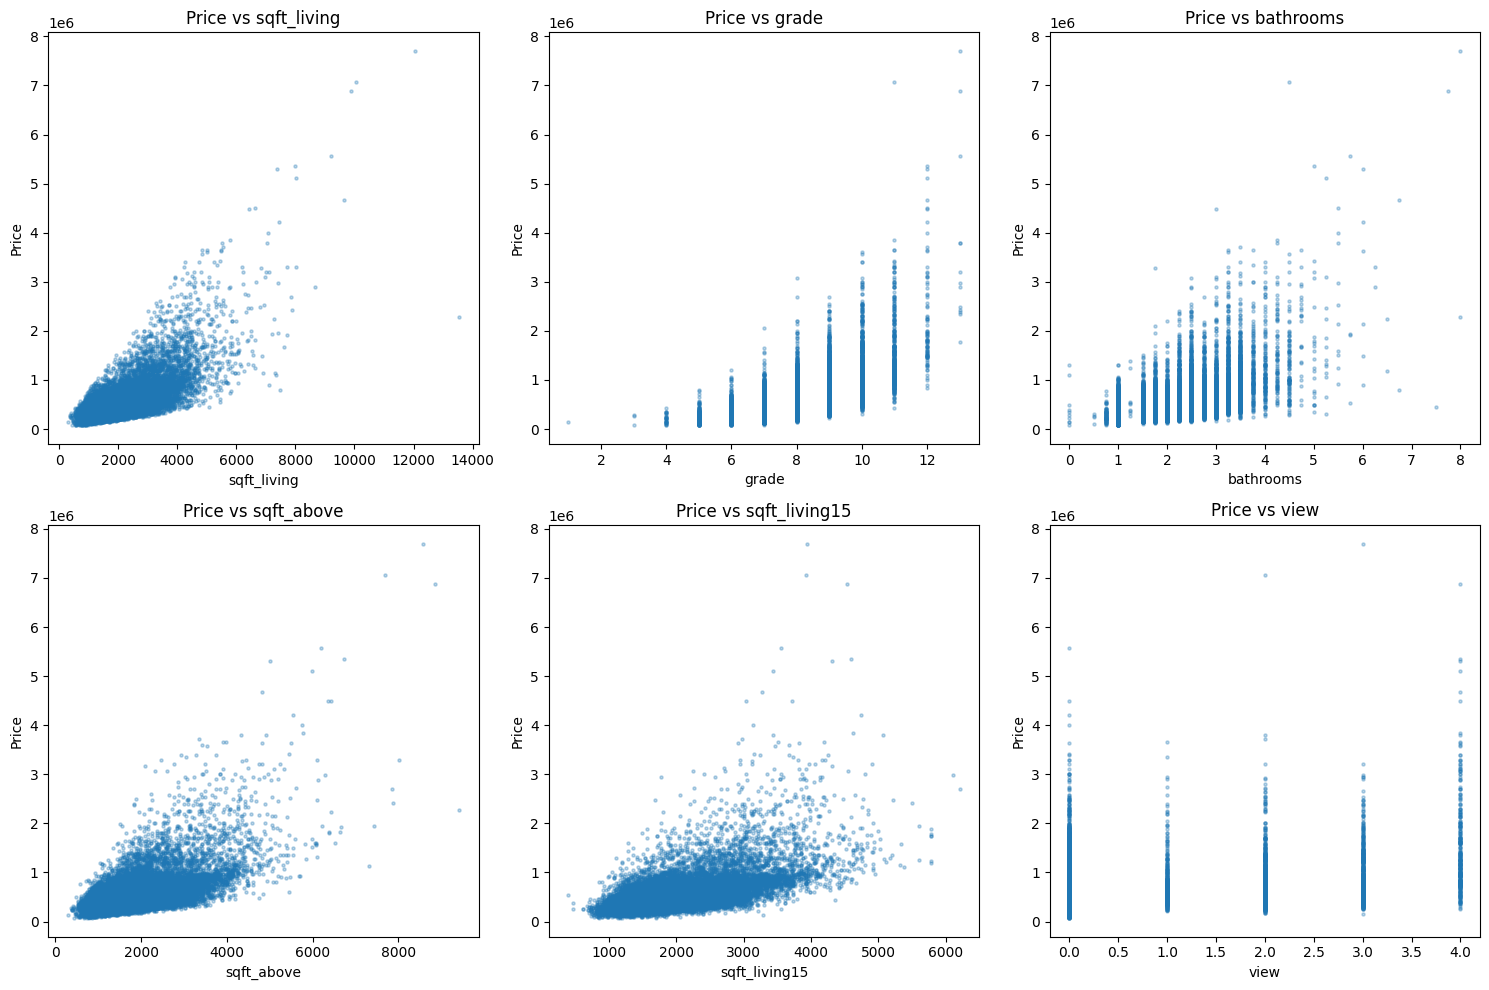

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features_to_plot = ["sqft_living", "grade", "bathrooms", "sqft_above", "sqft_living15", "view"]
for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df["price"], alpha=0.3, s=5)
    ax.set_xlabel(feat)
    ax.set_ylabel("Price")
    ax.set_title(f"Price vs {feat}")

plt.tight_layout()
plt.show()

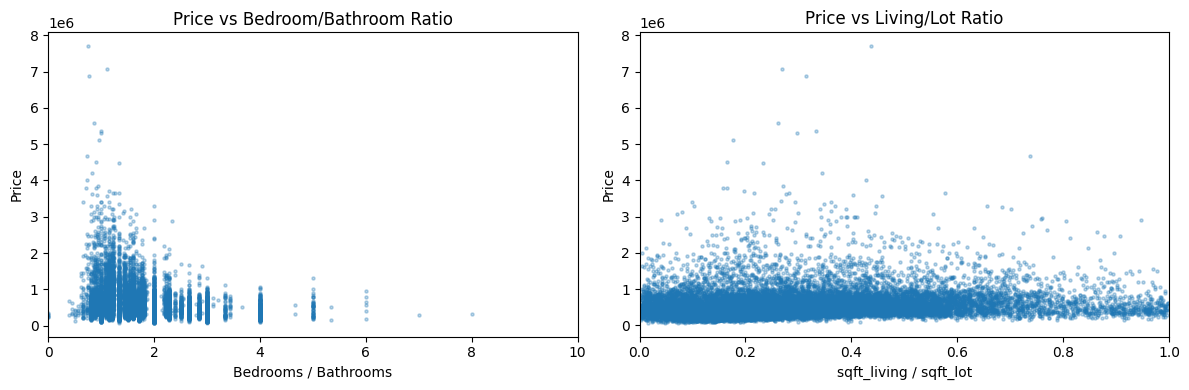

Correlation of bed/bath ratio with price: -0.249
Correlation of living/lot ratio with price: 0.123


In [ ]:
# Explore potential ratio features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bedroom to bathroom ratio
bed_bath_ratio = df["bedrooms"] / df["bathrooms"].replace(0, np.nan)
axes[0].scatter(bed_bath_ratio, df["price"], alpha=0.3, s=5)
axes[0].set_xlabel("Bedrooms / Bathrooms")
axes[0].set_ylabel("Price")
axes[0].set_title("Price vs Bedroom/Bathroom Ratio")
axes[0].set_xlim(0, 10)  # Limit x-axis for better visualization

# Living to lot ratio
living_lot_ratio = df["sqft_living"] / df["sqft_lot"].replace(0, np.nan)
axes[1].scatter(living_lot_ratio, df["price"], alpha=0.3, s=5)
axes[1].set_xlabel("sqft_living / sqft_lot")
axes[1].set_ylabel("Price")
axes[1].set_title("Price vs Living/Lot Ratio")
axes[1].set_xlim(0, 1)  # Most values are below 1

plt.tight_layout()
plt.show()

print(f"Correlation of bed/bath ratio with price: {bed_bath_ratio.corr(df['price']):.3f}")
print(f"Correlation of living/lot ratio with price: {living_lot_ratio.corr(df['price']):.3f}")

In [ ]:
df=df.drop(columns=["id"])

# ================================
# 🔴 CORRECCIÓN 2: ZIPCODE - ONE-HOT ENCODING
# ================================
print("=" * 60)
print("TRATAMIENTO DE ZIPCODE - CORRECCIÓN 2")
print("=" * 60)
print(f"Zipcodes únicos: {df['zipcode'].nunique()}")
print("Aplicando One-Hot Encoding al zipcode...")

# One-hot encoding para zipcode
zipcode_encoded = pd.get_dummies(df['zipcode'], prefix='zipcode', drop_first=True)
df = df.drop(columns=['zipcode'])
df = pd.concat([df, zipcode_encoded], axis=1)

print(f"✓ Zipcode convertido a {zipcode_encoded.shape[1]} columnas dummy")
print(f"✓ Nuevas dimensiones del dataset: {df.shape}\n")

X = df.drop(columns=["price"])
y = df["price"]

In [ ]:
# ================================
# 🔴 CORRECCIÓN 1: OUTLIERS - ANÁLISIS Y DETECCIÓN
# ================================
print("=" * 60)
print("ANÁLISIS DE OUTLIERS - CORRECCIÓN 1")
print("=" * 60)

# Detectar outliers usando IQR
def detectar_outliers_iqr(df, columnas):
    outliers = pd.DataFrame(index=df.index)
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[col] = (df[col] < lower_bound) | (df[col] > upper_bound)
    return outliers

# Columnas numéricas relevantes para outliers
columnas_outliers = ["price", "sqft_living", "sqft_lot", "bathrooms", "sqft_above", "sqft_basement"]
outliers_df = detectar_outliers_iqr(df, columnas_outliers)

print(f"Número total de filas: {len(df)}")
for col in columnas_outliers:
    outlier_count = outliers_df[col].sum()
    print(f"  {col}: {outlier_count} outliers ({100*outlier_count/len(df):.2f}%)")

# DECISIÓN: No eliminar outliers (pueden ser propiedades legítimamente caras)
# pero aplicar robust scaling en lugar de standard scaling
print("\n✓ Outliers detectados pero NO eliminados (son propiedades legítimas)")
print("✓ Se usará RobustScaler en lugar de StandardScaler\n")


In [ ]:
# ================================
# 🔴 CORRECCIÓN 1: OUTLIERS - ANÁLISIS Y DETECCIÓN
# ================================
print("=" * 60)
print("ANÁLISIS DE OUTLIERS - CORRECCIÓN 1")
print("=" * 60)

# Detectar outliers usando IQR
def detectar_outliers_iqr(df, columnas):
    outliers = pd.DataFrame(index=df.index)
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[col] = (df[col] < lower_bound) | (df[col] > upper_bound)
    return outliers

# Columnas numéricas relevantes para outliers
columnas_outliers = ["price", "sqft_living", "sqft_lot", "bathrooms", "sqft_above", "sqft_basement"]
outliers_df = detectar_outliers_iqr(df, columnas_outliers)

print(f"Número total de filas: {len(df)}")
for col in columnas_outliers:
    outlier_count = outliers_df[col].sum()
    print(f"  {col}: {outlier_count} outliers ({100*outlier_count/len(df):.2f}%)")

# DECISIÓN: No eliminar outliers (pueden ser propiedades legítimamente caras)
# pero aplicar robust scaling en lugar de standard scaling
print("\n✓ Outliers detectados pero NO eliminados (son propiedades legítimas)")
print("✓ Se usará RobustScaler en lugar de StandardScaler\n")


In [ ]:
#Procedemos a crear el modelo de regresión lineal
#Dividimos el dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3,random_state=42)
X_test, X_val,y_test,y_val= train_test_split(X_test,y_test,test_size=0.5,random_state=42)   



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler  # 🔴 CAMBIO: StandardScaler -> RobustScaler (mejor con outliers)
from sklearn.linear_model import LinearRegression

# 🔴 NOTA: Se usa RobustScaler en lugar de StandardScaler porque hay outliers en los datos
print("Creando modelo LR con RobustScaler (resistente a outliers)...")

modelo_lr= Pipeline([
    ("scaler", RobustScaler()),  # 🔴 Más robusto a valores extremos
    ("model", LinearRegression())
])

modelo_lr.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [ ]:
#EVALUACIÓN
from sklearn.metrics import mean_squared_error, r2_score #Porque es regresión, no clasificación
y_pred= modelo_lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print ("Mean Squared Error:" , mse)
print ("R2 Score:" , r2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

Mean Squared Error: 39683323214.15868
R2 Score: 0.7000065656979377
RMSE: 199206.7348614466


In [ ]:
#Realizamos el mismo proceso para el arbol de decisión
from sklearn.tree import DecisionTreeRegressor
modelo_tree = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    random_state=42
) #Evitamos overfitting limitando la profundidad del árbol y el número mínimo de muestras para dividir un nodo
modelo_tree.fit(X_train,y_train)
y_pred_tree= modelo_tree.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
print ("Mean Squared Error (Tree):" , mse_tree)
print ("R2 Score (Tree):" , r2_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
print("RMSE (Tree):", rmse_tree)


Mean Squared Error (Tree): 30193299931.558674
R2 Score (Tree): 0.7717481549995601
RMSE (Tree): 173762.1936197822


Como podemos ver el Decission Tree tuvo mejores resultados que el modelo de regresión lineal, tiene mayor R2 score y también tiene menos RMSE, esto indica que hay menos overfitting

In [ ]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42
)
#R2 score es el porcentaje de la variabilidad del precio explicado por el modelo, cuanto más cerca de 1 es mejor porque significa que explica mejor los datos reales

modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print ("Mean Squared Error (Random Forest):" , mse_rf)
print ("R2 Score (Random Forest):" , r2_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE (Random Forest):", rmse_rf)


Mean Squared Error (Random Forest): 18656402702.840626
R2 Score (Random Forest): 0.8589634671384945
RMSE (Random Forest): 136588.4427864987


Como podemos ver el random forest mejora aún más los resultados

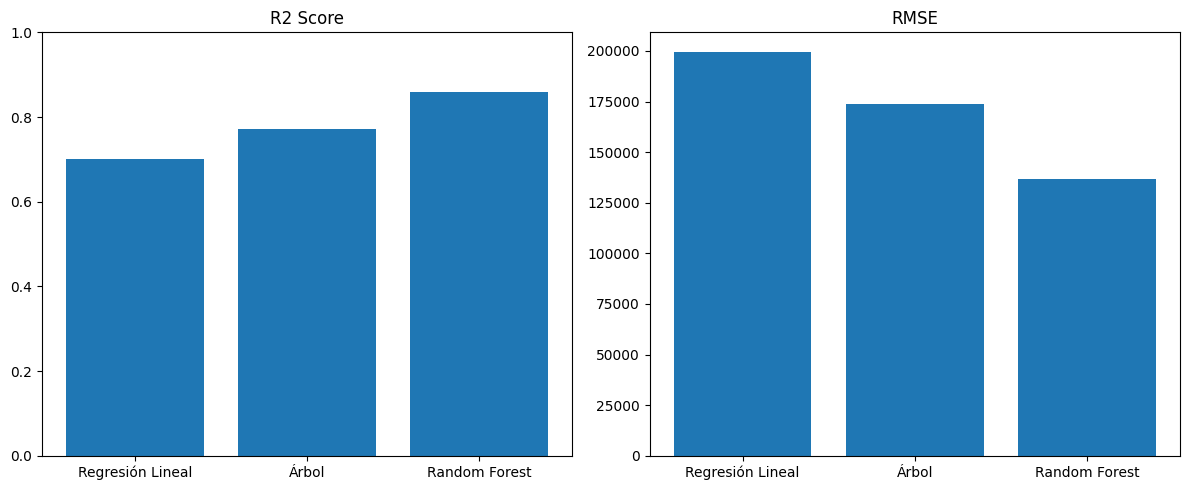

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
modelos = ["Regresión Lineal", "Árbol", "Random Forest"]
r2_scores = [r2, r2_tree, r2_rf]
rmse_scores = [rmse, rmse_tree, rmse_rf]

# R2
ax[0].bar(modelos, r2_scores)
ax[0].set_title("R2 Score")
ax[0].set_ylim(0,1)

# RMSE
ax[1].bar(modelos, rmse_scores)
ax[1].set_title("RMSE")

plt.tight_layout()
plt.show()

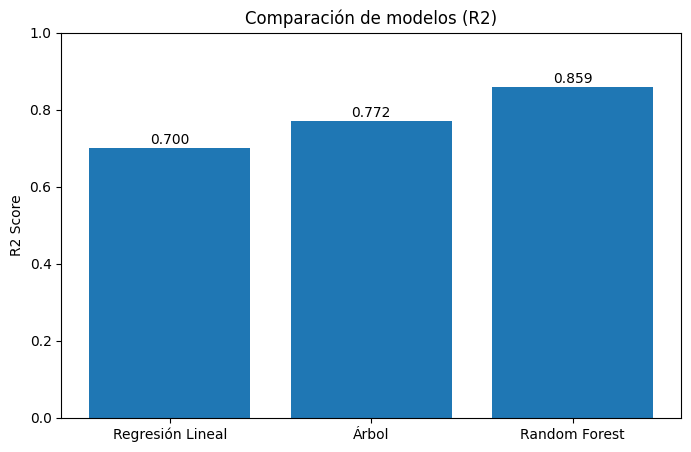

In [ ]:
import matplotlib.pyplot as plt

modelos = ["Regresión Lineal", "Árbol", "Random Forest"]
r2_scores = [r2, r2_tree, r2_rf]

plt.figure(figsize=(8,5))
plt.bar(modelos, r2_scores)

plt.title("Comparación de modelos (R2)")
plt.ylabel("R2 Score")
plt.ylim(0,1)

for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')

plt.show()

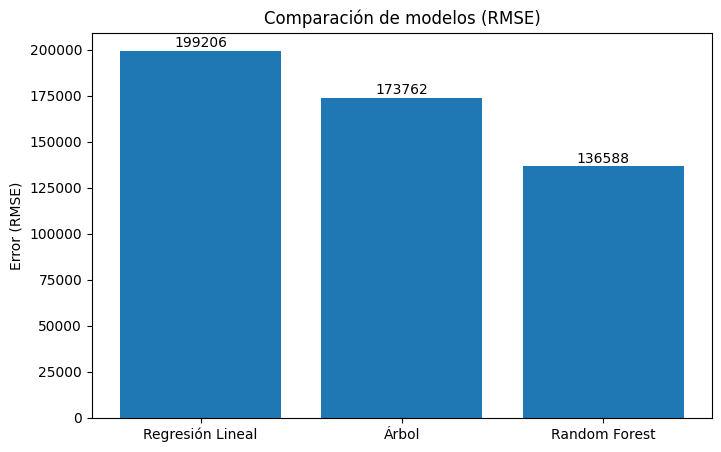

In [ ]:
rmse_scores = [rmse, rmse_tree, rmse_rf]

plt.figure(figsize=(8,5))
plt.bar(modelos, rmse_scores)

plt.title("Comparación de modelos (RMSE)")
plt.ylabel("Error (RMSE)")

for i, v in enumerate(rmse_scores):
    plt.text(i, v + 2000, f"{int(v)}", ha='center')

plt.show()

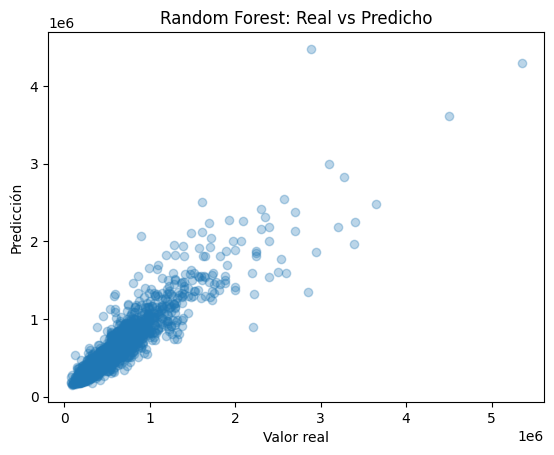

In [ ]:
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Random Forest: Real vs Predicho")
plt.show()

In [ ]:
#Vamos a usar el dataset de validación para comprobar el rendimiento del modelo con datos no vistos
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def evaluar_modelo(nombre, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {nombre} ---")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
    print()
    
    return rmse, r2

In [ ]:
modelo_lr.fit(X_train, y_train)

y_val_pred = modelo_lr.predict(X_val)
rmse_lr_val, r2_lr_val = evaluar_modelo("LR VAL", y_val, y_val_pred)

--- LR VAL ---
RMSE: 219299.50667780088
R2: 0.6925292685167881



In [ ]:
modelo_tree.fit(X_train, y_train)

y_val_pred_tree = modelo_tree.predict(X_val)
rmse_tree_val, r2_tree_val = evaluar_modelo("TREE VAL", y_val, y_val_pred_tree)

--- TREE VAL ---
RMSE: 186830.03716979234
R2: 0.7768371639232995



In [ ]:
modelo_rf.fit(X_train, y_train)

y_val_pred_rf = modelo_rf.predict(X_val)
rmse_rf_val, r2_rf_val = evaluar_modelo("RF VAL", y_val, y_val_pred_rf)

--- RF VAL ---
RMSE: 157965.5206681281
R2: 0.8404660647226068



In [ ]:
print("LR:", r2_lr_val)
print("Tree:", r2_tree_val)
print("RF:", r2_rf_val)

LR: 0.6925292685167881
Tree: 0.7768371639232995
RF: 0.8404660647226068


In [ ]:
y_test_pred = modelo_rf.predict(X_test)
evaluar_modelo("RF TEST", y_test, y_test_pred)
#Mediante esto evitamos el data leakage, ya que el modelo no ha visto los datos de validación durante el entrenamiento, por lo que la evaluación en este conjunto nos da una mejor idea de cómo se comportará el modelo con datos nuevos.

--- RF TEST ---
RMSE: 136588.4427864987
R2: 0.8589634671384945



(np.float64(136588.4427864987), 0.8589634671384945)

In [ ]:
resultados = {}

def evaluar_split(modelo, X, y):
    y_pred = modelo.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    return rmse, r2

In [ ]:
resultados["LR"] = {
    "train": evaluar_split(modelo_lr, X_train, y_train),
    "val": evaluar_split(modelo_lr, X_val, y_val),
    "test": evaluar_split(modelo_lr, X_test, y_test),
}

In [ ]:
resultados["Tree"] = {
    "train": evaluar_split(modelo_tree, X_train, y_train),
    "val": evaluar_split(modelo_tree, X_val, y_val),
    "test": evaluar_split(modelo_tree, X_test, y_test),
}

In [ ]:
resultados["RF"] = {
    "train": evaluar_split(modelo_rf, X_train, y_train),
    "val": evaluar_split(modelo_rf, X_val, y_val),
    "test": evaluar_split(modelo_rf, X_test, y_test),
}

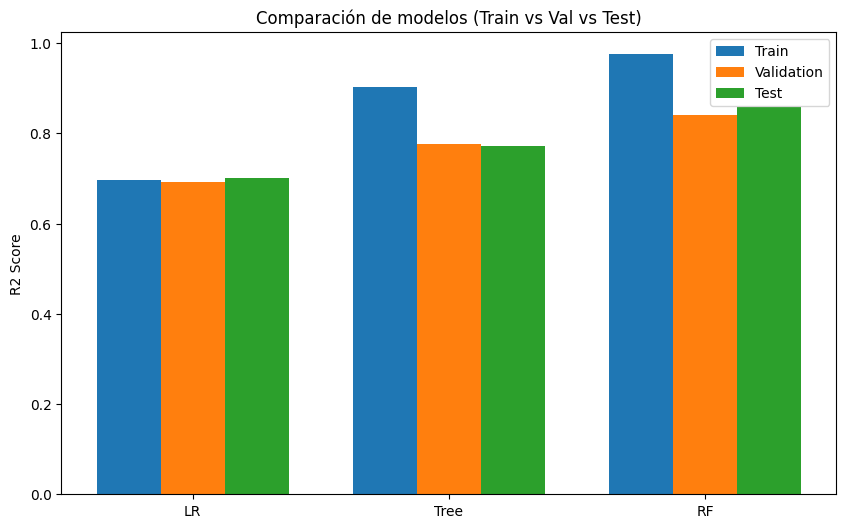

In [ ]:
import matplotlib.pyplot as plt

modelos = list(resultados.keys())

r2_train = [resultados[m]["train"][1] for m in modelos]
r2_val   = [resultados[m]["val"][1] for m in modelos]
r2_test  = [resultados[m]["test"][1] for m in modelos]

x = range(len(modelos))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar([i - width for i in x], r2_train, width, label="Train")
plt.bar(x, r2_val, width, label="Validation")
plt.bar([i + width for i in x], r2_test, width, label="Test")

plt.xticks(x, modelos)
plt.ylabel("R2 Score")
plt.title("Comparación de modelos (Train vs Val vs Test)")
plt.legend()

plt.show()

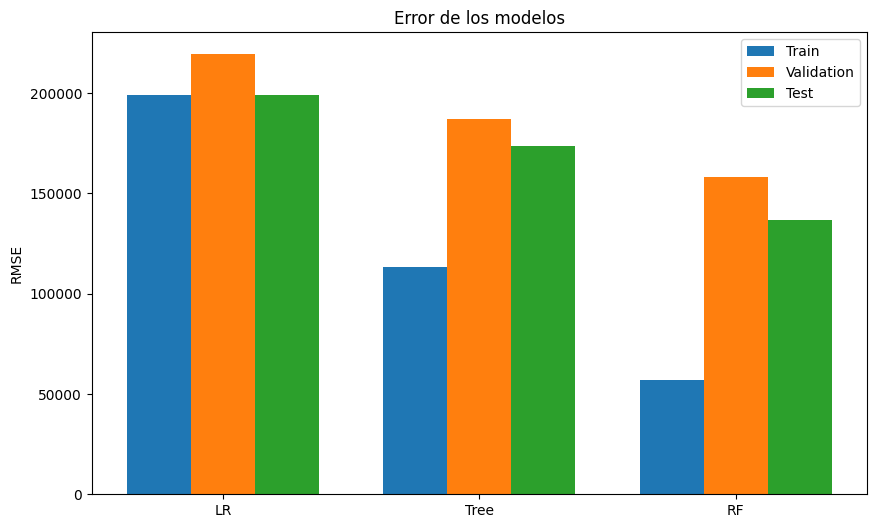

In [ ]:
rmse_train = [resultados[m]["train"][0] for m in modelos]
rmse_val   = [resultados[m]["val"][0] for m in modelos]
rmse_test  = [resultados[m]["test"][0] for m in modelos]

plt.figure(figsize=(10,6))

plt.bar([i - width for i in x], rmse_train, width, label="Train")
plt.bar(x, rmse_val, width, label="Validation")
plt.bar([i + width for i in x], rmse_test, width, label="Test")

plt.xticks(x, modelos)
plt.ylabel("RMSE")
plt.title("Error de los modelos")
plt.legend()

plt.show()

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
print (type(X_train))
print (type(y_train))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [ ]:
#Como son datos de pandas los debemos de convertir a Numpy para poder trabajar con Pytorch
X = X.values
y = y.values
X_train = X_train.values
y_train = y_train.values
X_test = X_test.values
y_test = y_test.values
X_val = X_val.values
y_val = y_val.values
print (type(X))
print (type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
print(X.dtype)
print (y.dtype)

float64
float64


In [ ]:
# Convertir a tensores de PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)  # X como float32 (no float64)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)  # y como float32
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Verificar los tipos de datos
print(X_train_tensor.dtype)  # Debería ser torch.float32
print(y_train_tensor.dtype)  # Debería ser torch.float32
print(X_val_tensor.dtype)  # Debería ser torch.float32
print(y_val_tensor.dtype)  # Debería ser torch.float32
print(X_test_tensor.dtype)  # Debería ser torch.float32
print(y_test_tensor.dtype)  # Debería ser torch.float32

torch.float32
torch.float32
torch.float32
torch.float32
torch.float32
torch.float32


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset= TensorDataset(X_train_tensor, y_train_tensor)
val_dataset= TensorDataset(X_val_tensor, y_val_tensor)
test_dataset= TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
#Creamos los dataloaders para poder iterar sobre los datasets
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True) #Igual a true para el entrenamiento, pero no para validación y test, ya que queremos evaluar el modelo con los datos en el mismo orden
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
#Vamos a crear una red neuronal simple con PyTorch
#Comprobamos las dimensaiones de los datos para crear la red neuronal
print (X_train_tensor.shape)  # Debería ser [n_samples, n_features]
print (y_train_tensor.shape)  # Debería ser [n_samples]

torch.Size([15129, 21])
torch.Size([15129])


In [ ]:
#Comenzamos a crear la red neuronal
import torch.nn as nn
class CountingSergio(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim):
        super(CountingSergio, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x
    

    #Parámetros de la red neuronal
input_dim= X_train_tensor.shape[1] #Número de características   
hidden_dim1=64
hidden_dim2=32
output_dim=1 #Número de clases

model= CountingSergio(input_dim,hidden_dim1, hidden_dim2, output_dim)

In [ ]:
#Pasamos a la perdida
criterion = nn.MSELoss() #Como es un problema de regresión, usamos MSELoss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epoch 0 | Train Loss: 100140687575.2370 | Val Loss: 97802970058.3047 | RMSE: 312734.6562
Epoch 1 | Train Loss: 85130725110.8118 | Val Loss: 91382856421.6262 | RMSE: 302295.9688
Epoch 2 | Train Loss: 81286507803.5307 | Val Loss: 87807855492.8168 | RMSE: 296323.9062
Epoch 3 | Train Loss: 78361437956.3487 | Val Loss: 82549341275.5978 | RMSE: 287314.0000
Epoch 4 | Train Loss: 74242920439.0656 | Val Loss: 79535994353.1548 | RMSE: 282021.2812
Epoch 5 | Train Loss: 73338067846.5062 | Val Loss: 79015415954.5564 | RMSE: 281096.8125
Epoch 6 | Train Loss: 71139051994.7396 | Val Loss: 76214801965.7989 | RMSE: 276070.2812
Epoch 7 | Train Loss: 71179874983.0117 | Val Loss: 75831535291.3017 | RMSE: 275375.2500
Epoch 8 | Train Loss: 71377583760.8788 | Val Loss: 76947110915.1585 | RMSE: 277393.4062
Epoch 9 | Train Loss: 71691484810.1104 | Val Loss: 77895617877.7545 | RMSE: 279097.8750
Epoch 10 | Train Loss: 69035683720.0629 | Val Loss: 75258636362.5416 | RMSE: 274333.0625
Epoch 11 | Train Loss: 7004185

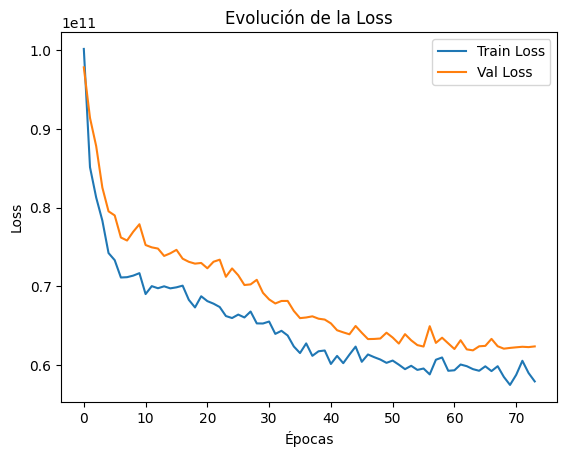

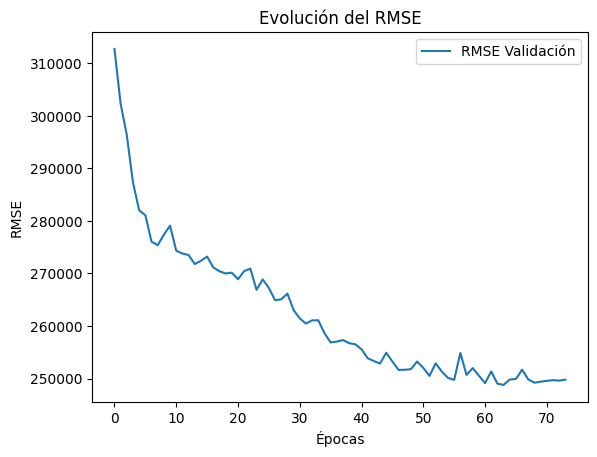

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

train_losses = []
val_losses = []
val_rmse_scores = []

num_epochs = 200

best_val_rmse = float('inf')
patience = 10
counter = 0

best_model_state = None

for epoch in range(num_epochs):
    
    # =====================
    # TRAIN
    # =====================
    model.train()
    running_loss_training = 0.0

    for X_batch, y_batch in train_dataloader:
        optimizer.zero_grad()
        
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        running_loss_training += loss.item() * X_batch.size(0)

    epoch_loss_training = running_loss_training / len(train_dataloader.dataset)
    train_losses.append(epoch_loss_training)

    # =====================
    # VALIDATION
    # =====================
    model.eval()
    running_loss_val = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_dataloader:
            
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            
            running_loss_val += loss.item() * X_batch.size(0)

            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_val_loss = running_loss_val / len(val_dataloader.dataset)
    val_losses.append(epoch_val_loss)

    # =====================
    # RMSE
    # =====================
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    rmse = np.sqrt(np.mean((all_preds - all_labels) ** 2))
    val_rmse_scores.append(rmse)

    print(f"Epoch {epoch} | Train Loss: {epoch_loss_training:.4f} | Val Loss: {epoch_val_loss:.4f} | RMSE: {rmse:.4f}")

    # =====================
    # EARLY STOPPING (RMSE)
    # =====================
    if rmse < best_val_rmse:
        best_val_rmse = rmse
        counter = 0
        
        # guardar mejor modelo
        best_model_state = model.state_dict()

    else:
        counter += 1

    if counter >= patience:
        print(f"🛑 Early stopping en epoch {epoch}")
        break

# =====================
# RESTAURAR MEJOR MODELO
# =====================
if best_model_state is not None:
    model.load_state_dict(best_model_state)


# =====================
# GRÁFICAS
# =====================
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Evolución de la Loss")
plt.legend()
plt.show()

plt.plot(val_rmse_scores, label="RMSE Validación")
plt.xlabel("Épocas")
plt.ylabel("RMSE")
plt.title("Evolución del RMSE")
plt.legend()
plt.show()

In [ ]:

# ================================
# 🔴 CORRECCIÓN 3: EVALUACIÓN EN TEST SET
# ================================
print("\n" + "=" * 60)
print("EVALUACIÓN EN TEST SET - CORRECCIÓN 3")
print("=" * 60)

model.eval()
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_dataloader:
        outputs = model(X_batch).squeeze()
        all_test_preds.extend(outputs.cpu().numpy())
        all_test_labels.extend(y_batch.cpu().numpy())

all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)

rmse_nn_test = np.sqrt(np.mean((all_test_preds - all_test_labels) ** 2))
r2_nn_test = 1 - (np.sum((all_test_preds - all_test_labels) ** 2) / np.sum((all_test_labels - np.mean(all_test_labels)) ** 2))

print(f"✓ RED NEURONAL - TEST SET:")
print(f"  RMSE: {rmse_nn_test:.4f}")
print(f"  R2: {r2_nn_test:.4f}\n")


In [ ]:
# ================================
# 🔴 CORRECCIÓN 4: COMPARACIÓN FINAL RF VS RED NEURONAL
# ================================
print("=" * 60)
print("COMPARACIÓN FINAL: RANDOM FOREST vs RED NEURONAL")
print("=" * 60)

# Obtener predicciones de RF en test set
y_pred_rf_final = modelo_rf.predict(X_test)
rmse_rf_final = np.sqrt(mean_squared_error(y_test, y_pred_rf_final))
r2_rf_final = r2_score(y_test, y_pred_rf_final)

print(f"\n📊 RESULTADOS EN TEST SET:")
print(f"\nRANDOM FOREST:")
print(f"  RMSE: {rmse_rf_final:.4f}")
print(f"  R2: {r2_rf_final:.4f}")

print(f"\nRED NEURONAL:")
print(f"  RMSE: {rmse_nn_test:.4f}")
print(f"  R2: {r2_nn_test:.4f}")

# Determinar ganador
if rmse_nn_test < rmse_rf_final:
    print(f"\n🏆 GANADOR: RED NEURONAL (RMSE {rmse_rf_final - rmse_nn_test:.2f} mejor)")
else:
    print(f"\n🏆 GANADOR: RANDOM FOREST (RMSE {rmse_nn_test - rmse_rf_final:.2f} mejor)")

print("\n" + "=" * 60)

# Visualización Comparativa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

modelos_finales = ["Random Forest", "Red Neuronal"]
r2_final = [r2_rf_final, r2_nn_test]
rmse_final = [rmse_rf_final, rmse_nn_test]

# R2 Scores
axes[0, 0].bar(modelos_finales, r2_final, color=['#2E86AB', '#A23B72'])
axes[0, 0].set_title("R2 Score en Test Set", fontsize=12, fontweight='bold')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(r2_final):
    axes[0, 0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

# RMSE
axes[0, 1].bar(modelos_finales, rmse_final, color=['#2E86AB', '#A23B72'])
axes[0, 1].set_title("RMSE en Test Set", fontsize=12, fontweight='bold')
for i, v in enumerate(rmse_final):
    axes[0, 1].text(i, v + 1000, f"${int(v)}", ha='center', fontweight='bold')

# Real vs Predicho - Random Forest
axes[1, 0].scatter(y_test, y_pred_rf_final, alpha=0.3, s=10, color='#2E86AB')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel("Precio Real")
axes[1, 0].set_ylabel("Predicción")
axes[1, 0].set_title("Random Forest: Real vs Predicho", fontweight='bold')

# Real vs Predicho - Red Neuronal
axes[1, 1].scatter(y_test, all_test_preds, alpha=0.3, s=10, color='#A23B72')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 1].set_xlabel("Precio Real")
axes[1, 1].set_ylabel("Predicción")
axes[1, 1].set_title("Red Neuronal: Real vs Predicho", fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Comparación completada\n")
